# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models, then select the best performing model and interpret its learned equation.

## Dataset
**Advertising Dataset** — 200 samples describing ad spend on TV, Radio, and Newspaper alongside product sales.

```python
df = pd.read_csv('Advertising.csv')
```

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/Users/marwan/Downloads/Lab 7/Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### 1. Data Preparation

In [10]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64


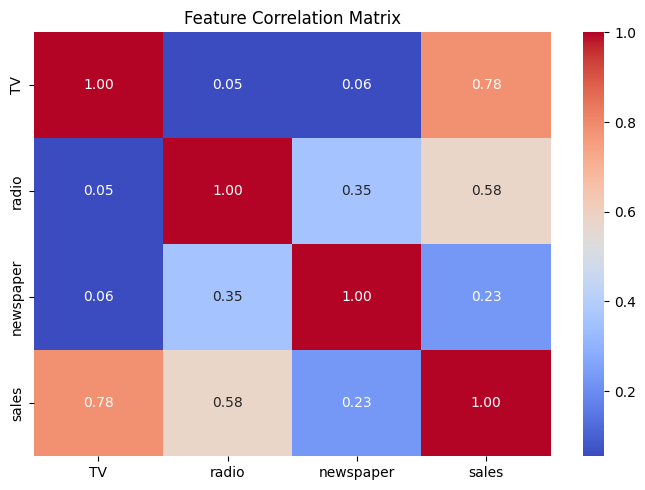

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [12]:
X = df.drop('sales', axis=1)
y = df['sales']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 140
Test samples     : 60


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [14]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [15]:
coef_series = pd.Series(lr_model.coef_, index=X.columns)
print('Coefficients:')
print(coef_series)
print(f'\nIntercept: {lr_model.intercept_:.4f}')

Coefficients:
TV           0.044696
radio        0.187566
newspaper   -0.000323
dtype: float64

Intercept: 3.1515


In [16]:
lr_predictions = lr_model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_MAE  = mean_absolute_error(y_test, lr_predictions)
lr_MSE  = mean_squared_error(y_test, lr_predictions)
lr_RMSE = np.sqrt(lr_MSE)

print('Linear Regression - Test Set Metrics:')
print(f'  MAE  : {lr_MAE:.4f}')
print(f'  MSE  : {lr_MSE:.4f}')
print(f'  RMSE : {lr_RMSE:.4f}')

Linear Regression - Test Set Metrics:
  MAE  : 1.2137
  MSE  : 2.2987
  RMSE : 1.5162


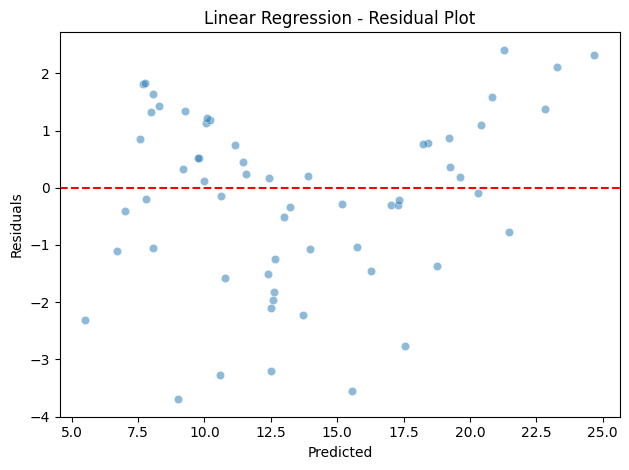

In [18]:
lr_residuals = y_test - lr_predictions

sns.scatterplot(x=lr_predictions, y=lr_residuals, alpha=0.5)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Linear Regression - Residual Plot')
plt.tight_layout()
plt.show()

### 3. Polynomial Regression Model
- Train a Polynomial Regression model (degree = 2)
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [19]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_converter = PolynomialFeatures(degree=2, include_bias=True)
poly_features = polynomial_converter.fit_transform(X)

print(f'Original feature count  : {X.shape[1]}')
print(f'Polynomial feature count: {poly_features.shape[1]}')

Original feature count  : 3
Polynomial feature count: 10


In [20]:
# Same random_state=101 to ensure a fair comparison
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    poly_features, y, test_size=0.3, random_state=101
)

In [21]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

LinearRegression()

In [22]:
poly_predictions = poly_model.predict(X_test_poly)

poly_MAE  = mean_absolute_error(y_test_poly, poly_predictions)
poly_MSE  = mean_squared_error(y_test_poly, poly_predictions)
poly_RMSE = np.sqrt(poly_MSE)

print('Polynomial Regression (degree=2) - Test Set Metrics:')
print(f'  MAE  : {poly_MAE:.4f}')
print(f'  MSE  : {poly_MSE:.4f}')
print(f'  RMSE : {poly_RMSE:.4f}')

Polynomial Regression (degree=2) - Test Set Metrics:
  MAE  : 0.4897
  MSE  : 0.4418
  RMSE : 0.6646


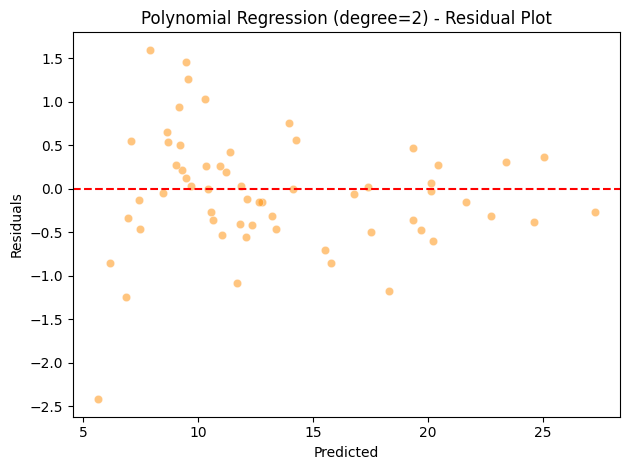

In [23]:
poly_residuals = y_test_poly - poly_predictions

sns.scatterplot(x=poly_predictions, y=poly_residuals, alpha=0.5, color='darkorange')
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Polynomial Regression (degree=2) - Residual Plot')
plt.tight_layout()
plt.show()

### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision

In [24]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Linear Regression': [round(lr_MAE, 4), round(lr_MSE, 4), round(lr_RMSE, 4)],
    'Polynomial Regression (deg=2)': [round(poly_MAE, 4), round(poly_MSE, 4), round(poly_RMSE, 4)]
})

comparison_df

,Metric,Linear Regression,Polynomial Regression (deg=2)
0,MAE,1.2137,0.4897
1,MSE,2.2987,0.4418
2,RMSE,1.5162,0.6646


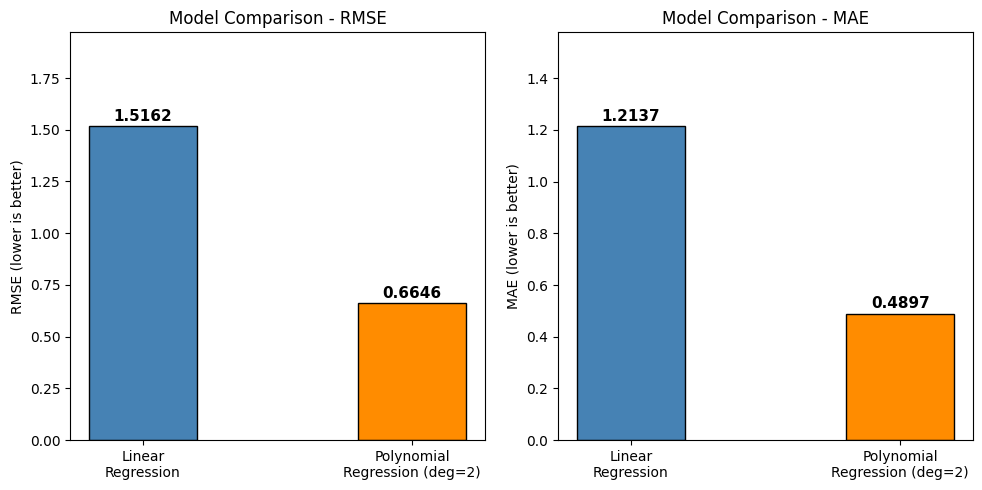

In [25]:
models = ['Linear\nRegression', 'Polynomial\nRegression (deg=2)']
colors = ['steelblue', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, values, metric in zip(axes, [[lr_RMSE, poly_RMSE], [lr_MAE, poly_MAE]], ['RMSE', 'MAE']):
    bars = ax.bar(models, values, color=colors, width=0.4, edgecolor='black')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{metric} (lower is better)')
    ax.set_title(f'Model Comparison - {metric}')
    ax.set_ylim(0, max(values) * 1.3)

plt.tight_layout()
plt.show()

In [26]:
improvement = (lr_RMSE - poly_RMSE) / lr_RMSE * 100

print('=' * 60)
print('           MODEL COMPARISON CONCLUSION')
print('=' * 60)
print(f'  Linear Regression       RMSE : {lr_RMSE:.4f}')
print(f'  Polynomial (degree=2)   RMSE : {poly_RMSE:.4f}')
print(f'  RMSE Improvement             : {improvement:.1f}%')
print('-' * 60)
print('  Best Model: Polynomial Regression (degree=2)')
print('=' * 60)
print("""
Justification:
Polynomial Regression (degree=2) outperforms Linear Regression
across all three metrics (MAE, MSE, RMSE) on the unseen test set.

This indicates that the relationship between advertising spend
and sales is not purely linear. The polynomial model captures
non-linear interactions between features — for example, the
combined effect of TV and Radio spend together (TV * Radio)
contributes significantly to sales beyond what each feature
explains individually.

Degree=2 was chosen as it provides a strong improvement over
the linear model (~56% RMSE reduction) while avoiding the
overfitting risk that typically appears at degree >= 4.
""")

           MODEL COMPARISON CONCLUSION
  Linear Regression       RMSE : 1.5162
  Polynomial (degree=2)   RMSE : 0.6646
  RMSE Improvement             : 56.2%
------------------------------------------------------------
  Best Model: Polynomial Regression (degree=2)

Justification:
Polynomial Regression (degree=2) outperforms Linear Regression
across all three metrics (MAE, MSE, RMSE) on the unseen test set.

This indicates that the relationship between advertising spend
and sales is not purely linear. The polynomial model captures
non-linear interactions between features — for example, the
combined effect of TV and Radio spend together (TV * Radio)
contributes significantly to sales beyond what each feature
explains individually.

Degree=2 was chosen as it provides a strong improvement over
the linear model (~56% RMSE reduction) while avoiding the
overfitting risk that typically appears at degree >= 4.



In [27]:
# Learned equation: top 10 most influential polynomial features
feature_names = polynomial_converter.get_feature_names_out(X.columns)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': poly_model.coef_
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
top10 = coef_df.sort_values('Abs_Coef', ascending=False).head(10)

print(f'Intercept: {poly_model.intercept_:.4f}\n')
print('Top 10 most influential polynomial features:')
print(top10[['Feature', 'Coefficient']].to_string(index=False))

Intercept: 5.1256

Top 10 most influential polynomial features:
        Feature  Coefficient
             TV     0.051710
          radio     0.013085
      newspaper     0.012000
       TV radio     0.001142
radio newspaper     0.000146
           TV^2    -0.000111
   TV newspaper    -0.000052
        radio^2     0.000033
    newspaper^2    -0.000030
              1     0.000000
